In [1]:
!pip install transformers[sentencepiece]
!pip install datasets
!pip install evaluate
!pip install accelerate
!pip show transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.1 MB/s eta 0:00:00
Name: transformers
Version: 4.42.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /opt/conda/lib/python3.10/site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: kaggle-environments


In [2]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# Prepare and preprocess data from Huggingface


## Load dataset from Huggingface

In [3]:
from datasets import load_dataset, DatasetDict
dataset = load_dataset("finkztah/youtube_trailer_comment_sentiment")

# The dataset only has training set, so we have to split it
train_testvalid = dataset['train'].train_test_split(test_size=0.3, shuffle=True, seed=42)

# Split the 40% test + valid in half test, half valid
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, shuffle=True, seed=42)

# Gather everything to have a single DatasetDict
dataset_split = DatasetDict({
    'train': train_testvalid['train'],
    'validation': test_valid['train'],
    'test': test_valid['test'],
})


Generating train split:   0%|          | 0/6962 [00:00<?, ? examples/s]

## Explore and preprocess the data

In [4]:
train = dataset_split['train']
train

Dataset({
    features: ['comment', 'title', 'video_id', 'labels', '__index_level_0__'],
    num_rows: 4873
})

In [5]:
train.features

{'comment': Value(dtype='string', id=None),
 'title': Value(dtype='string', id=None),
 'video_id': Value(dtype='string', id=None),
 'labels': Value(dtype='int64', id=None),
 '__index_level_0__': Value(dtype='int64', id=None)}

In [6]:
train[0]['comment']

'Cant wait'

### Preprocess

### Tokenize the data

In [7]:

from transformers import AutoTokenizer


checkpoint = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def preprocess(checkpoint, dataset: DatasetDict):
    ''' Preprocess data
      Args:
        checkpoint: the model that the tokenizer was trained on
        data: the data to be preprocessed
      Returns:
        inputs: the preprocessed data
    '''
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    def tokenize_fnc(example: dict):
        return tokenizer(example['comment'], truncation = True)

    tokenized_dataset = dataset.map(tokenize_fnc, batched=True)
    tokenized_dataset = tokenized_dataset.remove_columns(['comment', '__index_level_0__', 'title', 'video_id'])
    tokenized_dataset.set_format('torch')
    return tokenized_dataset



tokenized_dataset = preprocess(checkpoint, dataset_split)
tokenized_dataset






config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Map:   0%|          | 0/4873 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/1044 [00:00<?, ? examples/s]

Map:   0%|          | 0/1045 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 4873
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1044
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 1045
    })
})

### Load data into DataLoaders

In [8]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding


def load(tokenized_dataset, checkpoint, batch_size):
    # Load the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    data_collator = DataCollatorWithPadding(tokenizer = tokenizer)
    train_dataloader = DataLoader(tokenized_dataset['train'], shuffle = True, batch_size = batch_size, collate_fn = data_collator)
    valid_dataloader = DataLoader(tokenized_dataset['validation'], shuffle = True, batch_size = batch_size, collate_fn = data_collator)
    test_dataloader = DataLoader(tokenized_dataset['test'], shuffle = True, batch_size = batch_size, collate_fn = data_collator)
    return train_dataloader, valid_dataloader, test_dataloader

torch.manual_seed(42)
torch.cuda.manual_seed(42)
train_dataloader, valid_dataloader, test_dataloader = load(tokenized_dataset, checkpoint, 8)
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

2024-08-05 16:50:05.695041: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-05 16:50:05.695146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-05 16:50:05.812163: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


{'labels': torch.Size([8]),
 'input_ids': torch.Size([8, 46]),
 'attention_mask': torch.Size([8, 46])}

# Train the model on the dataset

In [9]:
from transformers import AutoModelForSequenceClassification
from transformers import AdamW, get_scheduler
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from transformers import logging
from accelerate import Accelerator
#Create Accelerator
accelerator = Accelerator()

# Set the logging level to 'ERROR' to suppress all warnings
logging.set_verbosity_error()

#Set random seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)
#Prepare model, optimizer and scheduler(decaying learning rate)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, ignore_mismatched_sizes=True, num_labels = 3)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-06)
epochs = 3
num_training_steps = epochs * len(train_dataloader)
lr_scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=num_training_steps,
)
#Put everything on accelerator
train_dataloader, valid_dataloader, model, optimizer = accelerator.prepare(train_dataloader, valid_dataloader, model, optimizer)


#We create a progress bar for visuals
progress_bar = tqdm(range(num_training_steps))

train_losses = []
valid_losses = []

#def train_loop(model, train_dataloader, valid_dataloader, epochs, optimizer):
for epoch in range(epochs):
#1. Forward loop
    model.train()
    loss_per_epoch = 0
    for batch in train_dataloader:
        outputs = model(**batch)
        #2. Calculate the loss
        loss = outputs.loss
        loss_per_epoch += loss.item()
        #3. Loss backward
        accelerator.backward(loss)
        #4. Update the gradient
        optimizer.step()
        #5. Zero grad
        optimizer.zero_grad()
        #6. Update the learning rate
        lr_scheduler.step()
        #7. Update the progress bar
        progress_bar.update(1)
    model.eval()
    # Calculate the average loss per epoch
    loss_per_epoch /= len(train_dataloader)
    with torch.inference_mode():
        valid_loss_per_epoch = 0
        for vbatch in train_dataloader:
            outputs = model(**vbatch)
            valid_outputs = model(**vbatch)
            valid_loss = valid_outputs.loss
            valid_loss_per_epoch += valid_loss.item()
        valid_loss_per_epoch /= len(valid_dataloader)
    train_losses.append(loss_per_epoch)
    valid_losses.append(valid_loss_per_epoch)
    print(f"Epoch: {epoch}, Loss: {loss_per_epoch}, Validation Loss: {valid_loss_per_epoch}")
#train_loop(model, train_dataloader, valid_dataloader, epochs, optimizer)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


  0%|          | 0/1830 [00:00<?, ?it/s]

Epoch: 0, Loss: 0.5032294974524956, Validation Loss: 1.632638801130971
Epoch: 1, Loss: 0.374255470842978, Validation Loss: 1.2802652349226347
Epoch: 2, Loss: 0.3118357561528683, Validation Loss: 1.1567270602774984


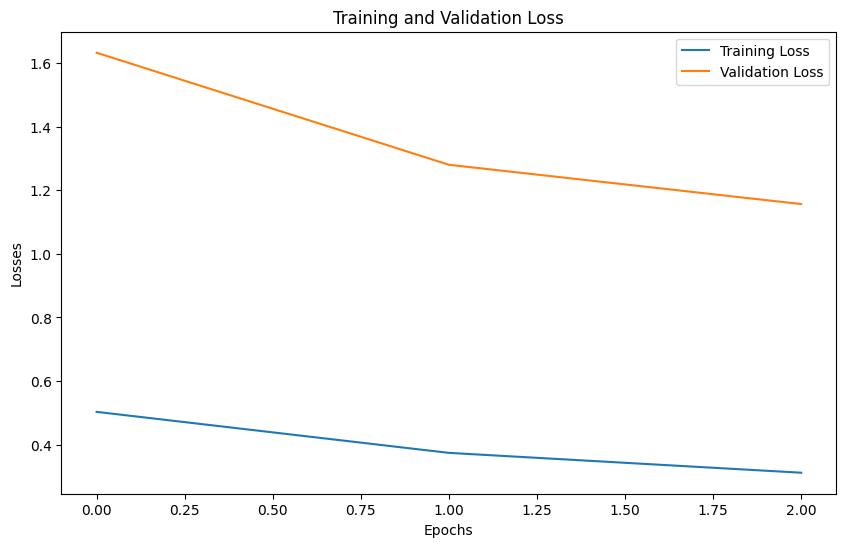

In [10]:
# Plot the train and valid curve
def plot_loss(train_losses, valid_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label = "Training Loss")
    plt.plot(valid_losses, label = "Validation Loss")
    plt.ylabel("Losses")
    plt.xlabel("Epochs")
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()



plot_loss(train_losses, valid_losses)

# Validate on the validation set

In [11]:
from evaluate import load

# Load the individual metrics
accuracy = load("accuracy")
f1 = load("f1")
precision = load("precision")
recall = load("recall")

metrics = [accuracy, f1, precision, recall]
def eval_loop(model, valid_dataloader, metrics):
  #1. Set to eval() mode
  model.eval()
  #2. Set to inference mode
  with torch.inference_mode():
    for batch in valid_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim = -1)
        for metric in metrics:
            metric.add_batch(predictions = predictions, references = batch['labels'])

    result = {}
    for metric in metrics:
        if metric == accuracy:
            result[metric.name] = metric.compute()[metric.name]
        else:
            result[metric.name] = metric.compute(average = None)[metric.name]
    return result


eval_loop(model, valid_dataloader, metrics)


{'accuracy': 0.8505747126436781,
 'f1': array([0.83677298, 0.7915937 , 0.89227642]),
 'precision': array([0.80797101, 0.85606061, 0.87103175]),
 'recall': array([0.86770428, 0.73615635, 0.91458333])}

In [12]:
# Try on the test set
eval_loop(model, test_dataloader, metrics)

{'accuracy': 0.8239234449760765,
 'f1': array([0.81063123, 0.75371901, 0.8810872 ]),
 'precision': array([0.80263158, 0.78350515, 0.86444444]),
 'recall': array([0.81879195, 0.72611465, 0.89838337])}

In [13]:
# Try back on the train set to see if overfit
eval_loop(model, train_dataloader, metrics)

{'accuracy': 0.9142212189616253,
 'f1': array([0.88981446, 0.87453323, 0.9527897 ]),
 'precision': array([0.86651917, 0.90986791, 0.94573991]),
 'recall': array([0.91439689, 0.8418404 , 0.95994538])}

In [14]:
from sklearn.metrics import classification_report
import torch

y_true = []
y_pred = []

with torch.inference_mode():
    for batch in valid_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1).tolist()
        y_pred.extend(predictions)
        y_true.extend(batch['labels'].tolist())

# Generate the classification report
report = classification_report(y_true, y_pred)
print(report)

        
        

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       257
           1       0.86      0.74      0.79       307
           2       0.87      0.91      0.89       480

    accuracy                           0.85      1044
   macro avg       0.85      0.84      0.84      1044
weighted avg       0.85      0.85      0.85      1044



In [15]:
# Try on the test set
from sklearn.metrics import classification_report
import torch

y_true = []
y_pred = []

with torch.inference_mode():
    for batch in test_dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1).tolist()
        y_pred.extend(predictions)
        y_true.extend(batch['labels'].tolist())

# Generate the classification report
report = classification_report(y_true, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       298
           1       0.78      0.73      0.75       314
           2       0.86      0.90      0.88       433

    accuracy                           0.82      1045
   macro avg       0.82      0.81      0.82      1045
weighted avg       0.82      0.82      0.82      1045



# Save the model 

In [16]:
from pathlib import Path

# 1. Create models directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path 
MODEL_NAME = "version1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model.state_dict(), # only saving the state_dict() only saves the models learned parameters
           f=MODEL_SAVE_PATH)

Saving model to: models/version1.pth
